In [1]:
!pip install transformers datasets evaluate accelerate scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/MyDrive/NLP_Project/cleaned_A_MASA.csv')

print(f"Data Loaded Successfully! Shape: {df.shape}")

Mounted at /content/drive
Data Loaded Successfully! Shape: (6074, 7)


**Tokenization**

In [3]:
from transformers import AutoTokenizer
from datasets import Dataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

texts = df['Sentences_clean'].astype(str).tolist()
labels = df['unified_sentiment'].tolist()

encoder = LabelEncoder()
encoded_labels = encoder.fit_transform(labels)
X_train, X_test, y_train, y_test = train_test_split(texts, encoded_labels, test_size=0.2, random_state=42, stratify=encoded_labels)

MODEL_NAME = "qarib/bert-base-qarib"
print(f"Downloading Tokenizer for {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

train_dataset = Dataset.from_dict({"text": X_train, "label": y_train})
test_dataset = Dataset.from_dict({"text": X_test, "label": y_test})

def tokenize_function(examples):
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing data...")
tokenized_train = train_dataset.map(tokenize_function, batched=True)
tokenized_test = test_dataset.map(tokenize_function, batched=True)

print("Tokenization Finished!")
print(tokenized_train)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/576 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Tokenizing data...


Map:   0%|          | 0/4859 [00:00<?, ? examples/s]

Map:   0%|          | 0/1215 [00:00<?, ? examples/s]

Tokenization Finished!
Dataset({
    features: ['text', 'label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 4859
})


In [4]:
import numpy as np
import torch
import evaluate
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(class_weight='balanced', classes=np.unique(y_train), y=y_train)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

print(f"Using Device: {device}")
print(f"Class Weights Tensor: {weights_tensor}")

clf_metrics = evaluate.combine(["accuracy", "f1", "precision", "recall"])

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return clf_metrics.compute(predictions=predictions, references=labels, average="weighted")

Using Device: cuda
Class Weights Tensor: tensor([2.8217, 4.9836, 0.4090], device='cuda:0')


**Custom Trainer**

In [5]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch import nn

print("Downloading QARiB Model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")
        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./qarib_results",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Starting Training with QARiB...")
trainer.train()

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: qarib/bert-base-qarib
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initial

Starting Training with QARiB...


Epoch,Training Loss,Validation Loss


TypeError: Accuracy._compute() got an unexpected keyword argument 'average'

In [7]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer
from torch import nn
import torch
import gc
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

torch.cuda.empty_cache()
gc.collect()
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, predictions, average='weighted', zero_division=0
    )
    acc = accuracy_score(labels, predictions)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

print("Downloading QARiB Model...")
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=3)

class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")
        outputs = model(**inputs)
        logits = outputs.get("logits")

        loss_fct = nn.CrossEntropyLoss(weight=weights_tensor)
        loss = loss_fct(logits.view(-1, self.model.config.num_labels), labels.view(-1))

        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./qarib_results",
    learning_rate=2e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=4,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=True,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_test,
    compute_metrics=compute_metrics,
)

print("Starting Training with QARiB (Fixed Metrics)...")
trainer.train()

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: qarib/bert-base-qarib
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initial

Starting Training with QARiB (Fixed Metrics)...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.597737,0.859259,0.862517,0.867450,0.859259
2,2.492599,0.690560,0.879012,0.874183,0.870491,0.879012
3,2.492599,0.911172,0.867490,0.868565,0.870065,0.867490
4,1.389654,1.143950,0.877366,0.876159,0.875450,0.877366


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=1216, training_loss=1.7706549920533832, metrics={'train_runtime': 530.7461, 'train_samples_per_second': 36.62, 'train_steps_per_second': 2.291, 'total_flos': 1278468096740352.0, 'train_loss': 1.7706549920533832, 'epoch': 4.0})

Predicting on Test Data...



QARiB Model - Final Classification Report
              precision    recall  f1-score   support

        -1.0       0.73      0.66      0.69       144
         0.0       0.41      0.42      0.42        81
         1.0       0.93      0.95      0.94       990

    accuracy                           0.88      1215
   macro avg       0.69      0.68      0.68      1215
weighted avg       0.88      0.88      0.88      1215



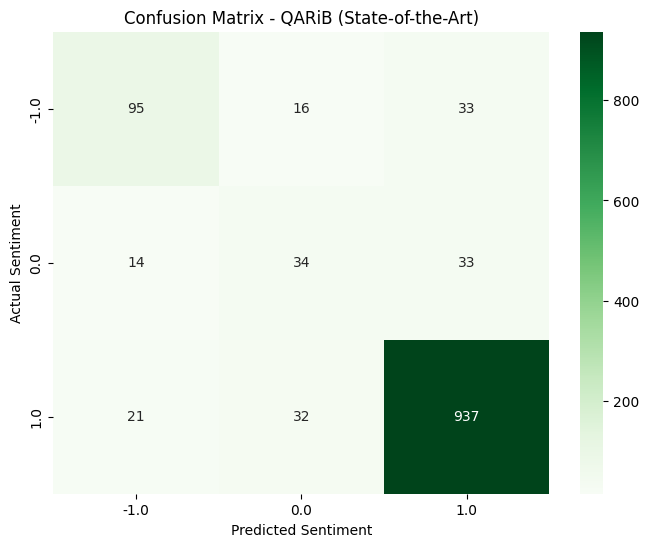

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("Predicting on Test Data...")
predictions_output = trainer.predict(tokenized_test)

y_pred = np.argmax(predictions_output.predictions, axis=1)
y_true = predictions_output.label_ids

target_names = [str(cls) for cls in encoder.classes_]

print("\n" + "="*50)
print("QARiB Model - Final Classification Report")
print("="*50)
print(classification_report(y_true, y_pred, target_names=target_names))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix - QARiB (State-of-the-Art)')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.show()